## Bulk RNA-seq Deconvolution with Geneformer Embeddings
This tutorial covers end-to-end bulk RNA-seq deconvolution in DECONVersation using Geneformer embeddings. It walks through extracting embeddings from bulk and single-cell reference data, building signature matrices, and estimating cell type proportions with all solvers available in DECONVersation. Performance is assessed against ground truth using RMSE and Pearson correlation. While this tutorial uses Geneformer, the workflow is fully compatible with Cell2Sentence, CellHermes and scGPT. <br>

### Import Libraries

In [18]:
import sys
import os
import pandas as pd
import numpy as  np
import scanpy as sc
#sys.path.insert(0, "/gpfs/commons/groups/compbio/projects/rf_projects/dev_deconv/DECONVersation/")
import deconversation
deconversation.__file__
from deconversation import embeddings, preprocessing, deconvolution, visualization, evaluation

### Step 1: Load data

In [8]:
# Read in bulk RNAseq data
hoek_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv", index_col=0)

# Geneformer requires ensembl ids, DECONVersation supports mapping gene  names to ids 
hoek_bulk.index = preprocessing.gene_id_name_map(gene_list=hoek_bulk.index, mode="to_ensembl" ) 
hoek_bulk = hoek_bulk.loc[hoek_bulk.index.dropna()] # Drop unmapped genes

# Inspect bulk data
hoek_bulk.iloc[0:4, 0:4].head()

,HD30_PBMC_0,HD30_PBMC_1,HD30_PBMC_3,HD30_PBMC_7
ENSG00000259429,8,2,10,18
ENSG00000215529,35,35,30,26
ENSG00000231649,0,0,0,0
ENSG00000253542,0,0,0,0


In [9]:
# Load scRNA-seq reference data 
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/haoSub.h5ad"
adata = sc.read_h5ad(path_ref)
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC', 'pDC'])]

# Ensure adata.var are ensembl ids (required for geneformer) - switch to gene names for scGPT. cellHermes and C2S
adata.var.index = adata.var.gene_id
adata = adata[:, adata.var.index.notnull()] 

In [10]:
# load ground truth data
ground_truth = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_facs.csv", index_col=0)
ground_truth = ground_truth.T

# Inspect data
ground_truth.iloc[0:4, 0:4].head()

,T cell,Monocytes,B cells,mDC
HD30_PBMC_0,0.514,0.155,0.043,0.0264
HD30_PBMC_1,0.457,0.214,0.048,0.0251
HD30_PBMC_3,0.580,0.153,0.042,0.0172
HD30_PBMC_7,0.578,0.135,0.066,0.0184


### Step 2: Create signature matrix using scRNA reference data

In [32]:
sig_mat = preprocessing.create_signature_matrix(adata = adata,
                                  sample_col = "batch", # batch or donor id column
                                  cell_type_col = "broad_type", # cell type column to average 
                                  groupby = "broad_type",
                                  output_path = None)

# Transpose for embedding extraction
sig_mat = sig_mat.T

# Inspect signature matrix
sig_mat.iloc[0:4, 0:4].head()

/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/preprocessing.py:259: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


gene_id,ENSG00000121410,ENSG00000268895,ENSG00000148584,ENSG00000175899
broad_type,,,,
B cells,0.217336,0.031785,0.000449,0.001496
Monocytes,0.349243,0.037201,0.000062,0.002642
NK cells,0.086643,0.009497,0.000167,0.009497
T cells,0.267866,0.019023,0.000210,0.009827


### Step 3: Extract geneformer embeddings on signature matrix and bulk data

In [33]:
# Extract geneformer embeddings on signature matrix
sig_mat_gf = embeddings.extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

In [34]:
# Extract geneformer embeddings on bulk data
bulk_gf = embeddings.extract_embs(
    bulk_df = hoek_bulk.T, # sample x ensembl id
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",  # Default geneformer model
    delete_temp_files = True # if True, delete all temporary files created whiile extracting embeddings
)

### Step 3:  Run deconvolution

In [38]:
# Run deconvolution
results = deconvolution.run_all_deconv(bulk_df = bulk_gf.T, 
                         signature_df = sig_mat_gf.T)

# Harmonize results to match ground truth
def harmonize_columns(df):
    df = df.copy()
    if "pDC" in df.columns and "mDC" in df.columns:
        df["mDC"] = df["mDC"] + df["pDC"]
        df = df.drop(columns=["pDC"])
    elif "pDC" in df.columns:       
        df = df.rename(columns={"pDC": "mDC"})
    df = df.rename(columns={"T cells": "T cell"})
    return df


# Harmonize results to match ground truth
results = {solver: harmonize_columns(df) for solver, df in results.items()}

### Step 4: Visualize results

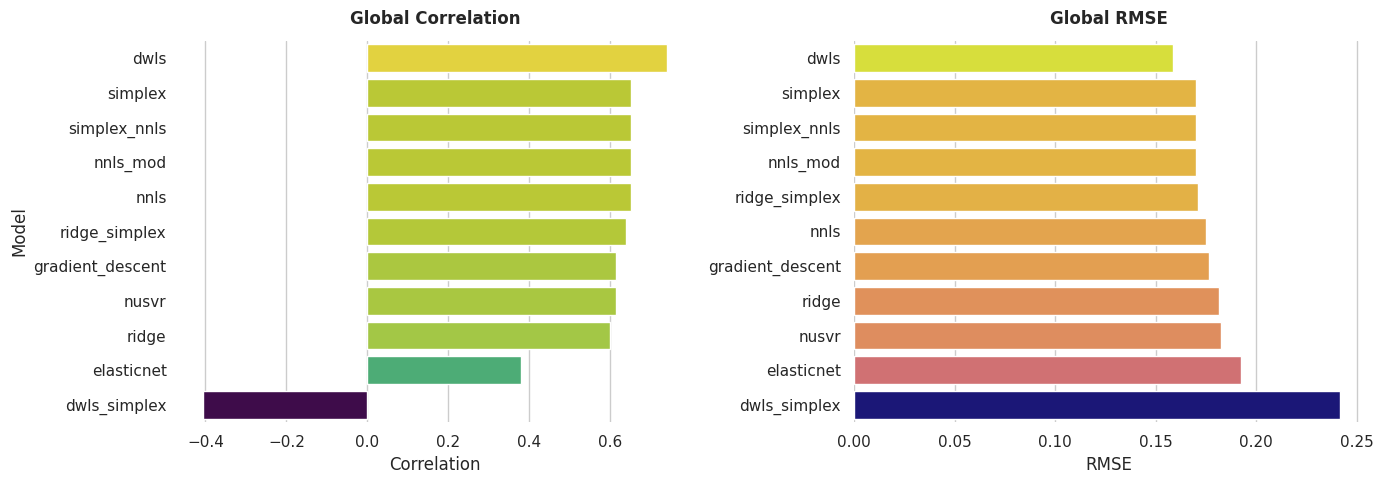

In [39]:
# Visualize results 
visualization.visualize_solvers(results, 
                  ground_truth, 
                  level=["global"])

### Compare with PCA

In [40]:
# Extract principal components frm bulk data and signature matrix 
# Fit on signature matrix and apply on  bulk
sig_mat_bulk_pca = embeddings.extract_components(bulk_df = hoek_bulk.T,
                                                 sig_mat = sig_mat,
                                                 mode = "pca",
                                                 transform = True)

bulk_pca = sig_mat_bulk_pca["pca_bulk"]
sig_mat_pca = sig_mat_bulk_pca["sig_pca"]

In [41]:
# Run deconvolution
results_pca = deconvolution.run_all_deconv(bulk_df=bulk_pca.T, 
                                      signature_df=sig_mat_pca.T)

results_pca = {solver: harmonize_columns(df) for solver, df in results_pca.items()}

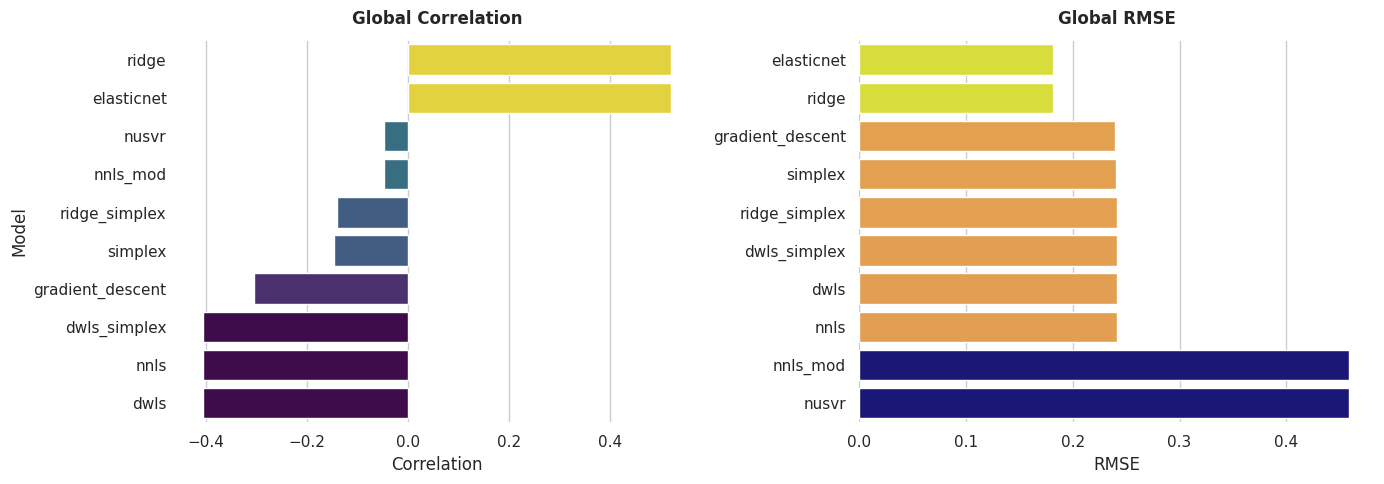

In [42]:
# Visualize results 
visualization.visualize_solvers(results_pca, 
                  ground_truth, 
                  level=["global"])

### Extra
Embeddings can also be extarcted directly using the core functions if both bulk data and signature matrix have been saved as csv files. 

In [65]:
temp = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/haoSub_sig_mat_id.csv", index_col=0)

In [5]:
res = deconversation.deconverse(
    bulk_df = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv",
    adata = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/haoSub.h5ad",
    model = "ctheodoris/Geneformer",
    mode = "geneformer",
    cell_type_col = "broad_type",
    sample_col = "batch",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/tempgf/")

Using model: geneformer


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 27.36it/s]

Bulk data rows are not ENSG ids, converting...
Extracting signature embedding...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 144.03it/s]

Extracting bulk embedding...


  0%|          | 0/1 [00:00<?, ?it/s]

Solving deconvolution...


In [19]:
def harmonize_columns(df):
    df = df.copy()
    if "pDC" in df.columns and "mDC" in df.columns:
        df["mDC"] = df["mDC"] + df["pDC"]
        df = df.drop(columns=["pDC"])
    elif "pDC" in df.columns:       
        df = df.rename(columns={"pDC": "mDC"})
    df = df.rename(columns={"T cells": "T cell"})
    return df


# Harmonize results to match ground truth
results = harmonize_columns(res)

# Inspect results:
results.head()

broad_type,B cells,Monocytes,NK cells,Platelet,T cell,mDC
HD30_PBMC_0,0.0,0.364570,0.040373,0.309813,0.275984,0.009259
HD30_PBMC_1,0.0,0.399857,0.111210,0.310578,0.171286,0.007068
HD30_PBMC_3,0.0,0.337491,0.014011,0.316831,0.324410,0.007257
HD30_PBMC_7,0.0,0.308938,0.034612,0.325392,0.314413,0.016646
HD31_PBMC_0,0.0,0.401556,0.000000,0.314202,0.284242,0.000000


In [23]:
evaluation.compute_correlation(true_df=ground_truth, pred_df=results)

np.float64(0.6441903227837804)

In [24]:
evaluation.compute_rmse(true_df=ground_truth, pred_df=results)

np.float64(0.16756961607937954)

In [22]:
sys.path.insert(0, "/gpfs/commons/groups/compbio/projects/rf_projects/dev_deconv/DECONVersation/")
import deconversation